# Morphological operators to perform image manipulation and filtering

__Author(s):__ Masa Prodanovic

__Last Update:__ July 2026

Copyright © 2025 Digital Porous Media Team. All rights reserved.

---

Morphological image processing is a collection of non-linear operations related to the shape or morphology of features in an image, such as boundaries, skeletons, etc. In any given technique, we probe an image with a small shape or template called a structuring element, which defines the region of interest or neighborhood around a pixel. We have introduced that in the previous lecture on grayscale image filtering.

For the most part, we will focus on morphological processing binary (segmented images) as it is very useful in creating input for further simulation in digital rock physics. However all of the operations exemplified here are work for any type of __binary or grayscale__ image but __not color__ images (i.e. cannot use them directly on images with 3 or 4 channels).

## Morphological Filtering

Morphological image processing is a collection of non-linear operations related
to the shape or morphology of features in an image, such as boundaries,
skeletons, etc. In any given technique, we probe an image with a small shape or
template called a structuring element, which defines the region of interest or
neighborhood around a pixel.

We outline the following basic morphological operations:

1. Erosion
2. Dilation
3. Opening
4. Closing
5. White Tophat
6. Black Tophat
7. Medial axis and skeletonization
8. Advanced: creating a graph based on medial axis and exploring percolation

To get started, let's import all of the needed tools and load an image using ``io.imread``.
Note that morphology functions only work on gray-scale or binary images; if reading in color images convert them during readin using option ``as_gray=True``.

We are first going to use a simple binary image with disks. The workflow here assumes a binary image (i.e. image with two values such as 0 and 255, often shown as black and white).

In [1]:
# import all tools
from pathlib import Path
import sys
sys.path.append("..")
from utils.dataloader import load_sample
download_path = Path("/home/jovyan/work/ls6/dpm_teach_cache")

# skimage tools
import skimage.io as io
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import white_tophat, black_tophat, medial_axis, skeletonize
from skimage.morphology import disk

# basic array manipulation and plotting
import matplotlib.pyplot as plt
import numpy as np

# labeling connected components
from scipy.ndimage import label

## Install networkx
try:
    import networkx as nx
except ModuleNotFoundError:    
    !pip install networkx
    import networkx as nx

import itertools
from matplotlib.gridspec import GridSpec
from edt import edt




__Let's also define a convenience function for plotting comparisons:__

In [3]:
def basic_image_stats(img):
    print(f"Shape: {img.shape}")
    print(f"Data type: {img.dtype}")
    print(f"Value range: [{img.min()}, {img.max()}]")
    
    # calculate fractions
    min_fraction = (img == img.min()).mean()
    max_fraction = (img == img.max()).mean()
    
    print(f"Fraction of points with min value:{min_fraction:0.4f}")
    print(f"Fraction of points with max value:{max_fraction:0.4f}")
    print(f"Sum of the fractions is {min_fraction+max_fraction}")


def plot_comparison(original, filtered, filter_name='filtered',filter_cmap = plt.cm.gray):
    fig = plt.figure(figsize=(8, 4))

    # 1 row, 3 columns: image1 | image2 | colorbar
    gs = GridSpec(1, 3, width_ratios=[1, 1, 0.05], figure=fig)

    # First image (left)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('image')
    ax1.axis('off')

    # Second image (middle)
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(filtered, cmap=filter_cmap)
    ax2.set_title(filter_name)
    ax2.axis('off')

    # Colorbar axis (right)
    cax = fig.add_subplot(gs[0, 2])
    cbar = fig.colorbar(im2, cax=cax)
    cbar.set_label('Intensity')

    plt.tight_layout()
    plt.show()
    

## Read an image

In [ ]:
# Read dry beads image
# dry_beads_img = load_sample('beads_dry_slice', cache_dir=download_path)
# filename = Path("../images/beads_dry_slice_bin.tif")
# basename  = 'beads_dry_slice_bin'


# filename = Path("../images/sierpinski_carpet_512x512.tif")
# # resulting images will be saved using basename below
# basename  = 'sierpinski_carpet' 

# Read Sierpinski Carpet image
data = load_sample('sierpinski_carpet', cache_dir=download_path)


[  0 255]


### Report basic information about the image

Shape: (512, 512)
Data type: uint8
Value range: [0, 255]
Fraction of points with min value:0.7039
Fraction of points with max value:0.2961
Sum of the fractions is 1.0


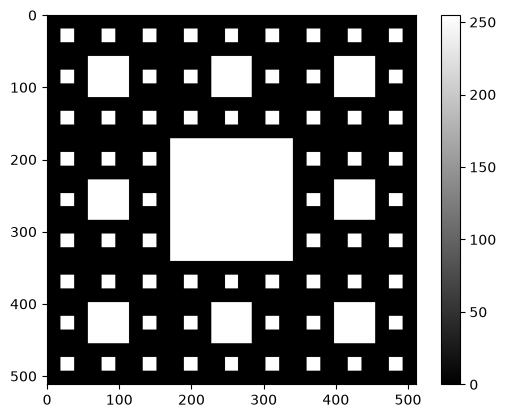

In [21]:
basic_image_stats(data)
plt.imshow(data, cmap=plt.cm.gray)
plt.colorbar()

## Erosion

Morphological ``erosion`` sets a pixel at (i, j) to the __minimum over all
pixels in the neighborhood centered at (i, j)__. The structuring element,
``footprint``, passed to ``erosion`` is a boolean array that describes this
neighborhood. Below, we use ``disk`` to create a circular structuring
element, which we use for most of the following examples.



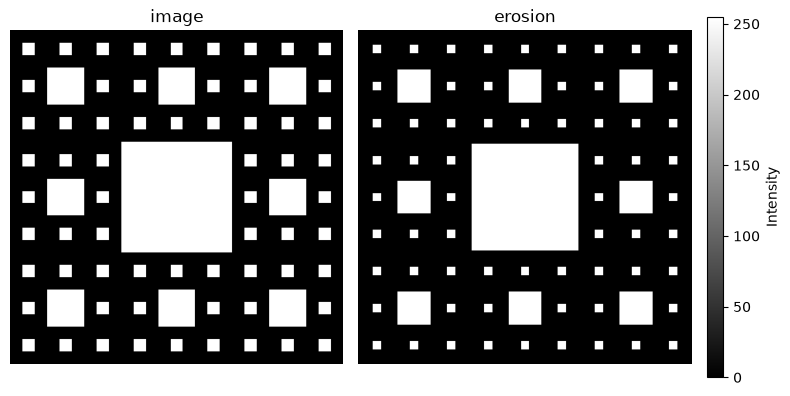

In [22]:
footprint = disk(3)
eroded = erosion(data, footprint)
plot_comparison(data, eroded, 'erosion')

__Exercise__: Play with size of the disk and notice how the white boundary of the image disappears or gets eroded (and the black phase dilated!) as we increase the size of the disk.

## Dilation

Morphological ``dilation`` sets a pixel at (i, j) to the __maximum over all
pixels in the neighborhood centered at (i, j)__. Dilation enlarges bright
regions and shrinks dark regions.



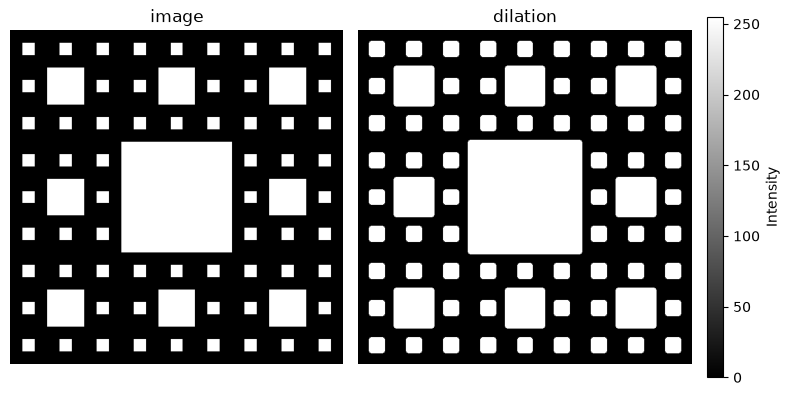

In [23]:
dilated = dilation(data, footprint)
plot_comparison(data, dilated, 'dilation')

__Exercise__: Note how the white boundary of the image thickens, or gets dilated, as we
increase the size of the disk (footprint).

## Opening

Morphological ``opening`` on an image is defined as an *erosion followed by
a dilation*. Opening can remove small bright spots (i.e. "salt") and
connect small dark cracks.



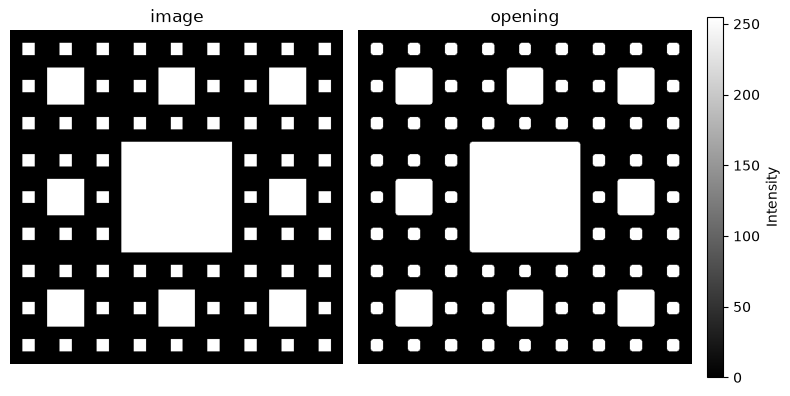

In [24]:
opened = opening(data, footprint)
plot_comparison(data, opened, 'opening')

Since ``opening`` an image starts with an erosion operation, light regions
that are *smaller* than the structuring element are removed. The dilation
operation that follows ensures that light regions that are *larger* than
the structuring element retain their original size.

## Closing

Morphological ``closing`` on an image is defined as a *dilation followed by
an erosion*. Closing can remove small dark spots (i.e. "pepper") and
connect small bright cracks.





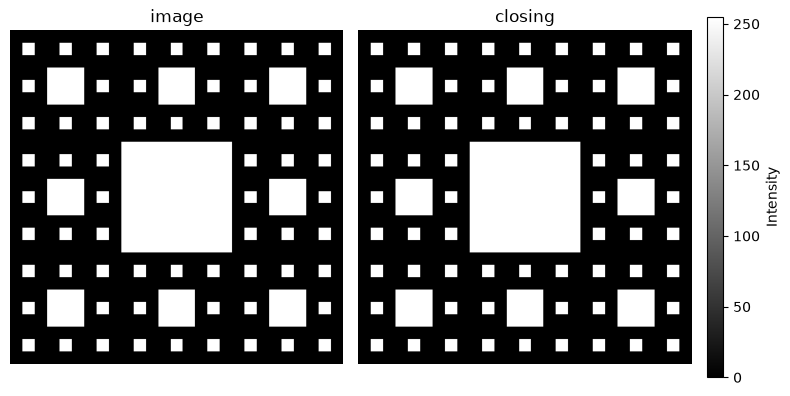

In [25]:
closed = closing(data, footprint)
plot_comparison(data, closed, 'closing')

Since ``closing`` an image starts with an dilation operation, dark regions
that are *smaller* than the structuring element are removed. The dilation
operation that follows ensures that dark regions that are *larger* than the
structuring element retain their original size. 

## White tophat

The ``white_tophat`` of an image is defined as the *image minus its
morphological opening*. This operation returns the bright spots of the
image that are smaller than the structuring element. These are the ones that were removed during the opening operation.


__Note on grayscale image operations__: these operations work on grayscale images, too, and can be used for filtering dark and light objects smaller than certain size. See skimage documentation for examples:
- https://scikit-image.org/docs/stable/auto_examples/filters/plot_tophat.html
- https://scikit-image.org/docs/stable/auto_examples/filters/plot_attribute_operators.html




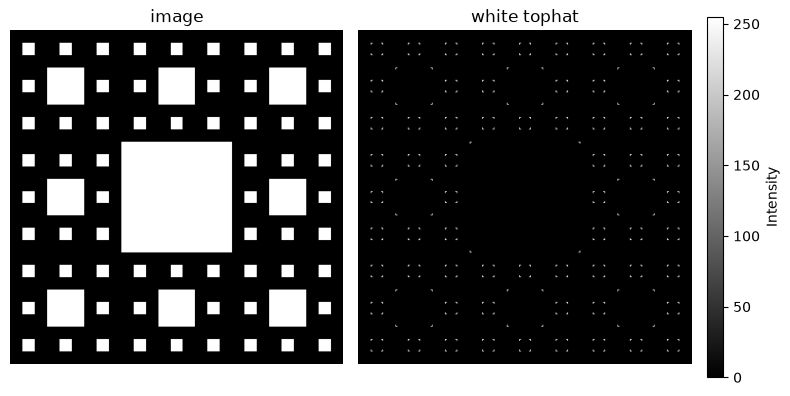

In [26]:
w_tophat = white_tophat(data, footprint)
plot_comparison(data, w_tophat, 'white tophat')


## Black tophat

The ``black_tophat`` of an image is defined as its morphological **closing
minus the original image**. This operation returns the *dark spots of the
image that are smaller than the structuring element*. These are the ones that were removed during the closing operation.



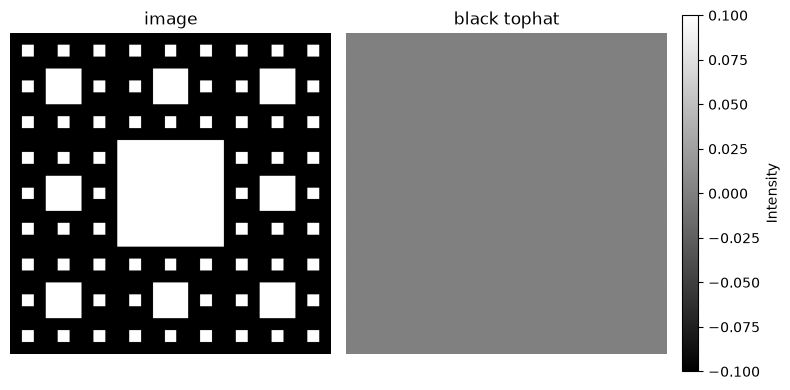

In [27]:
b_tophat = black_tophat(data, footprint)
plot_comparison(data, b_tophat, 'black tophat')

# Selecting (the main) connected component of the image

We will now choose one of the filtered images above and analyze the connected components of one of the phases of interest in this image.
This is not a morphological operation in itself, but a common algorithm for identifying different objects as well as for  preparing the image for futher analysis or simulation, for instance.

In [28]:
# assuming here that the image we want to work with below is 'eroded'
# we want to find the main (largest) connected component of this image.

def label_components_return_main(img):
    # Label connected components
    labeled_img, num_features = label(img)
    
    if num_features > 0:
      # Count sizes of each component (ignore background label 0)
      component_sizes = np.bincount(labeled_img.ravel())
      component_sizes[0] = 0
    
      # Find the label of the largest component
      main_label = component_sizes.argmax()
    
      # Create binary mask for the main component
      main_component = labeled_img == main_label
    else:
      main_component = np.copy(img)
    
    plot_comparison(img, labeled_img,'connected components','inferno')

    return(main_component)

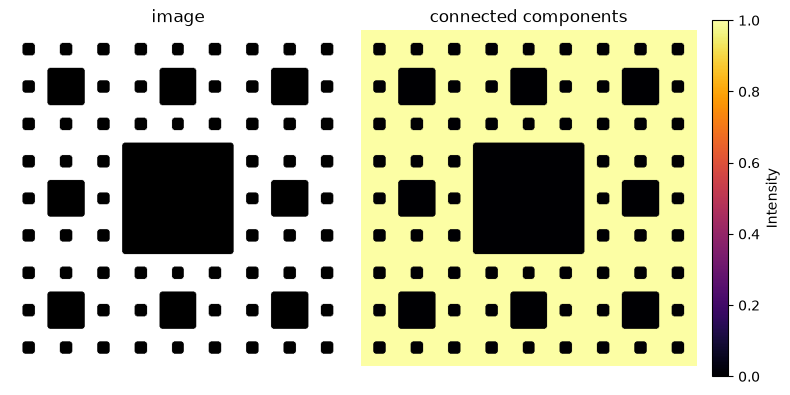

In [29]:
# Define what to work with from here on
img = (opened == 0)

main_component = label_components_return_main(img)

# save this geometry into a tif file
# filename = basename + '-filtered.tif'
# img_to_write = main_component == 1
# tifffile.imwrite(filename, img_to_write)
# print('\nFiltered geometry saved in file',filename) 


## Medial axis of a selected phase

Thinning is used to reduce each connected component in a binary image to a
*single-pixel wide skeleton*. It is important to note that this is
performed on binary images only.

We here take the main component of the filtered image (see previous section) and find the medial axis. There are two algorithms you can play with in 2D below.



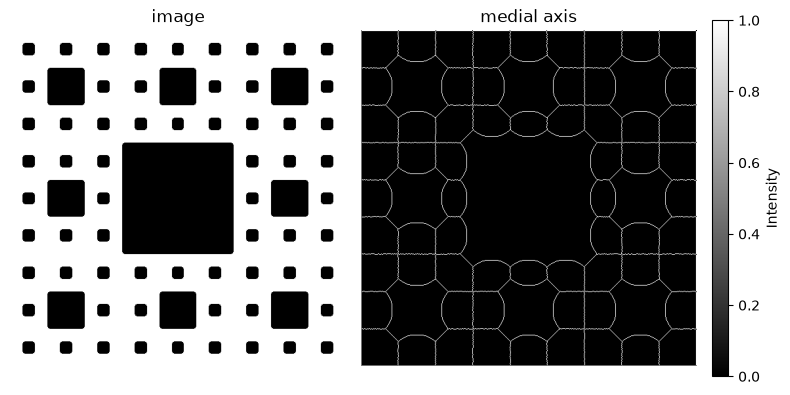

In [30]:
ma = medial_axis(main_component == 1)
plot_comparison(main_component, ma, 'medial axis')

#sk = skeletonize(eroded == 0,method='lee')
#plot_comparison(eroded, sk, 'skeletonize')

## Euclidean distance transform

Euclidian distance transform (edt) function available in dpm_tools computes for every pixel of the phase 255 (white) the distance to the closest phase 0 pixel (black).

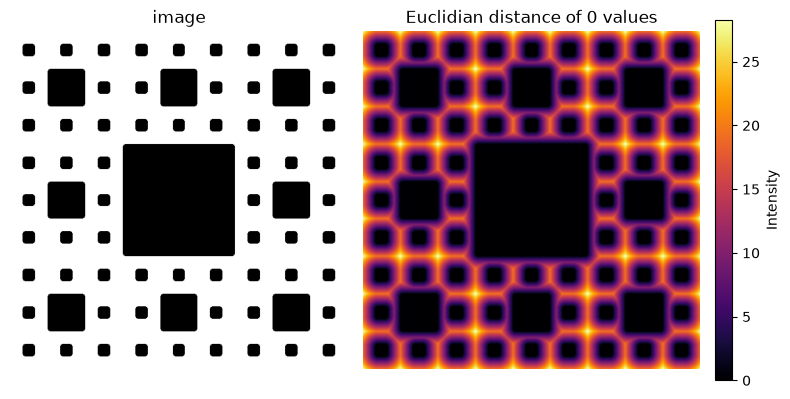

In [31]:
dt = edt(main_component==1)
plot_comparison(main_component,dt,'Euclidian distance of 0 values','inferno')


## Advanced: creating a graph based on medial axis and exploring percolation

To analyze connectivity quantitatively, we convert the medial axis image into a graph that `networkx` can operate on. The cell below defines the helper functions we'll use:

- `medial_axis_to_graph`: turns every medial-axis pixel into a graph node, connecting it to its 8 neighboring medial-axis pixels (edge weight = pixel-to-pixel distance).
- `simplify_graph`: collapses long chains of degree-2 nodes (i.e. points along a simple path with no branching) into single weighted edges, keeping only endpoints and junctions. This drastically reduces graph size without losing topology.
- `component_spanning_left_to_right`: extracts the connected component of the graph that touches both the leftmost and rightmost columns of the image — i.e. the part of the pore network that *percolates* across the image.
- `find_paths_across`: finds the shortest path(s) through the spanning component from every leftmost node to every rightmost node.
- `plot_top_k_paths`: visualizes the `k` shortest left-to-right paths, sorted by total path length.


In [32]:
# utility functions

# Graph building from medial axis. This translates every 
# medial axis pixel to a node in the graph
def medial_axis_to_graph(ma):
    """Convert medial axis image to a NetworkX graph (pixel-level)."""
    G = nx.Graph()
    rows, cols = np.nonzero(ma)
    for r, c in zip(rows, cols):
        G.add_node((r, c))
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if 0 <= nr < ma.shape[0] and 0 <= nc < ma.shape[1]:
                    if ma[nr, nc]:
                        G.add_edge((r, c), (nr, nc), weight=np.hypot(dr, dc))
    return G


# Graph simplification
def simplify_graph(G):
    ### Merge degree-2 nodes (those with only two neighbors) into single edges, 
    ### while preserving all branches.
    H = nx.Graph()
    visited_edges = set()

    def walk_chain(start, neighbor):
        path = [start]
        current = neighbor
        prev = start
        total_dist = G[prev][current]['weight']
        while G.degree[current] == 2:
            nbrs = list(G.neighbors(current))
            nxt = nbrs[0] if nbrs[1] == prev else nbrs[1]
            total_dist += G[current][nxt]['weight']
            prev, current = current, nxt
        path.append(current)
        return path, total_dist

    for node in G.nodes:
        if G.degree[node] != 2:  # endpoint or junction
            for nbr in G.neighbors(node):
                edge_key = tuple(sorted([node, nbr]))
                if edge_key in visited_edges:
                    continue
                chain, dist = walk_chain(node, nbr)
                end_node = chain[-1]
                H.add_node(node)
                H.add_node(end_node)
                H.add_edge(node, end_node, weight=dist, pixels=chain)
                visited_edges.add(edge_key)
    return H


# Find graph component that spans from left to right
def component_spanning_left_to_right(G):
    """Return the subgraph of the component that spans from leftmost to rightmost nodes."""
    if G.number_of_nodes() == 0:
        return G

    min_col = min(n[1] for n in G.nodes)
    max_col = max(n[1] for n in G.nodes)

    for comp_nodes in nx.connected_components(G):
        cols = [n[1] for n in comp_nodes]
        if min(cols) == min_col and max(cols) == max_col:
            return G.subgraph(comp_nodes).copy()

    return nx.Graph()  # No spanning component found

# Find all paths going from left to right
def find_paths_across(G):
    """Find all shortest paths from leftmost to rightmost nodes in the spanning component."""
    if not G.nodes:
        return []

    min_col = min(n[1] for n in G.nodes)
    max_col = max(n[1] for n in G.nodes)

    left_nodes = [n for n in G.nodes if n[1] == min_col]
    right_nodes = [n for n in G.nodes if n[1] == max_col]

    paths = []
    for start, end in itertools.product(left_nodes, right_nodes):
        try:
            path = nx.shortest_path(G, source=start, target=end, weight='weight')
            paths.append(path)
        except nx.NetworkXNoPath:
            continue
    return paths

# Plot a selection of shortest paths
def plot_top_k_paths(ma, G_spanning, paths, k=1):
    """
    Plot up to k shortest paths on the simplified spanning graph.
    Paths are sorted by total weight (distance).
    """
    if not paths:
        print("No paths to plot.")
        return

    # Sort paths by total weight
    sorted_paths = sorted(
        paths,
        key=lambda p: sum(
            G_spanning[p[i]][p[i+1]]['weight'] for i in range(len(p)-1)
        )
    )

    npath = len(sorted_paths)
    path_total_weights = np.zeros(npath)

    for i in range(npath):
        path = sorted_paths[i]
        path_total_weights[i] = nx.path_weight(G_spanning, path, weight='weight')
        

    # Take up to k paths
    top_paths = sorted_paths[:k]

    plt.figure(figsize=(8, 8))
    plt.imshow(ma, cmap='gray')

    colors = plt.cm.jet(np.linspace(0, 1, len(top_paths)))

    i = 0
    for path, col in zip(top_paths, colors):
        rr = [n[0] for n in path]
        cc = [n[1] for n in path]
        plt.plot(cc, rr, color=col, linewidth=2, label=f"Len: {path_total_weights[i]:4.2f}")

    # Draw graph nodes
    nx.draw_networkx_nodes(
        G_spanning,
        pos={n: (n[1], n[0]) for n in G_spanning.nodes},
        node_size=20,
        node_color='white',
        edgecolors='black'
    )

    plt.title(f"Top {len(top_paths)} Shortest Paths Across")
    plt.axis('off')
    plt.legend()
    plt.show()

    return sorted_paths,path_total_weights


### Constructing the graph and checking for percolation

We now build the full pixel-level graph from the medial axis, simplify it, and extract the component that spans from the left to the right edge of the image. If a spanning component exists (and paths are found), the phase we selected percolates across the image; if not, this phase is disconnected from one side to the other.

In [33]:
# Create graph using above medial axis

# Every pixel on medial axis is converted to a graph node, and if two pixels are connected,
# an edge is created between them
G_full = medial_axis_to_graph(ma)

# The full graph is an overkill, we can merge many nodes that have only two neighbors
G_simple = simplify_graph(G_full)

# Get spanning component
G_spanning = component_spanning_left_to_right(G_simple)

print(f"Original graph: {len(G_full.nodes)} nodes, {len(G_full.edges)} edges")
print(f"Simplified graph: {len(G_simple.nodes)} nodes, {len(G_simple.edges)} edges")
print(f"Spanning component: {len(G_spanning.nodes)} nodes, {len(G_spanning.edges)} edges")

# Find paths
simp_paths = find_paths_across(G_spanning)
print(f"Found {len(simp_paths)} paths from leftmost to rightmost nodes.")


Original graph: 8561 nodes, 8674 edges
Simplified graph: 226 nodes, 339 edges
Spanning component: 226 nodes, 339 edges
Found 64 paths from leftmost to rightmost nodes.


### Visualizing the graph at each stage

The three panels below show, from left to right: the raw pixel-level graph built directly from the medial axis, the simplified graph restricted to the percolating (spanning) component, and all the shortest left-to-right paths found within that spanning component.


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

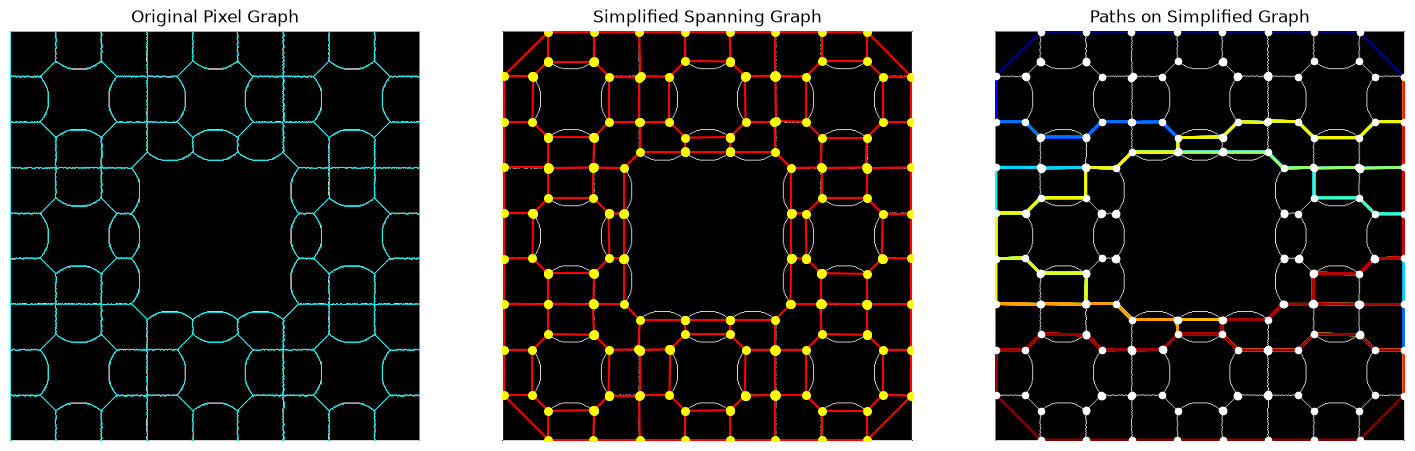

In [34]:
# Plotting results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Original pixel graph
axes[0].imshow(ma, cmap='gray')
for u, v in G_full.edges:
    axes[0].plot([u[1], v[1]], [u[0], v[0]], color='cyan', linewidth=0.5)
axes[0].set_title("Original Pixel Graph")
axes[0].axis('off')

# Plot 2: Simplified spanning graph
axes[1].imshow(ma, cmap='gray')
for u, v in G_spanning.edges:
    axes[1].plot([u[1], v[1]], [u[0], v[0]], color='red', linewidth=1.5)
nx.draw_networkx_nodes(G_spanning, pos={n: (n[1], n[0]) for n in G_spanning.nodes},
                       node_size=30, node_color='yellow', ax=axes[1])
axes[1].set_title("Simplified Spanning Graph")
axes[1].axis('off')

# --- Plot 3: Paths on simplified spanning graph ---
axes[2].imshow(ma, cmap='gray')
colors = plt.cm.jet(np.linspace(0, 1, len(simp_paths)))
for path, col in zip(simp_paths, colors):
    rr = [p[0] for p in path]
    cc = [p[1] for p in path]
    axes[2].plot(cc, rr, color=col, linewidth=2)

nx.draw_networkx_nodes(
    G_spanning,
    pos={n: (n[1], n[0]) for n in G_spanning.nodes},
    node_size=20,
    node_color='white',
    ax=axes[2]
)

axes[2].set_title("Paths on Simplified Graph")
axes[2].axis('off')

### Shortest percolating paths

Here we highlight the `k` shortest paths across the image, colored and ranked by their total (weighted) length. These represent the most direct routes through the pore network from one side of the image to the other.


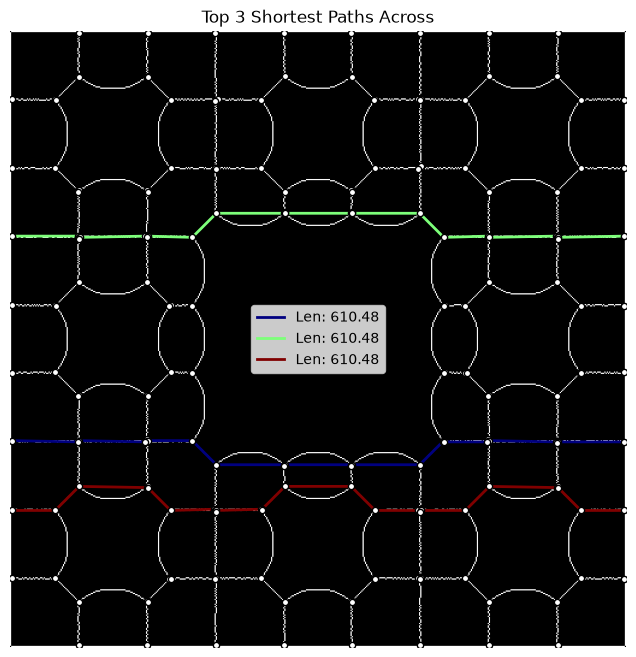

In [35]:
# Plot the shortest path going from left to right
sorted_paths, path_weights = plot_top_k_paths(ma, G_spanning, simp_paths, k=3)

### Path length statistics

Finally, we normalize the shortest-path lengths by the image width to report the minimum, maximum, and average path length as a dimensionless "tortuosity-like" measure — a value close to 1 indicates a nearly straight path, while larger values indicate a more tortuous route through the pore space.


In [36]:
# Path length stats
img_width,img_height = img.shape
ave_weight = np.mean(path_weights)/img_width
min_weight = np.min(path_weights)/img_width
max_weight = np.max(path_weights)/img_width
print(f"\nPath lengths from left to right normalized by image width: Min {min_weight:1.4f} Max {max_weight:1.4f} Ave {ave_weight:1.4f}")
print(f"\nImage width: {img_width} pixels")


Path lengths from left to right normalized by image width: Min 1.1923 Max 1.8971 Ave 1.4516

Image width: 512 pixels
